# 04 · Quick strategy test in pure Python

The hypothesis in notebook 03 had a real, OOS-surviving edge *before costs*. Now we ask the only question that pays: **does it still make money after spread + slippage, and how risky is the ride?**

This is a **vectorized backtest** — no loops over trades, no C++, no MT5. Pure numpy/pandas math. It is intentionally a *fast filter*: 'is there enough here to justify the heavyweight C++ tick engine?'. It is **not** a substitute for it (see the honesty section at the end).

> Project rule, front and center: **uncosted backtests are fantasy.** We model real spread from the bar data.

## Block 0 · Setup + load (with real spread for costs)

In [1]:
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
try:
    import seaborn as sns; sns.set_theme(style='whitegrid')
except ImportError: pass

ROOT = Path.cwd()
while not (ROOT/'CLAUDE.md').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
DATA = ROOT/'data'
bars_glob = str(DATA/'processed'/'bars_btcusd_M3_*.parquet')

df = duckdb.sql(f"""
    SELECT f.ts, f.close, f.adx, f.di_plus, f.di_minus, f.dist_poc, f.hour,
           l.fwd_ret_10, b.spread_mean
    FROM '{DATA}/features/features_btcusd_M3.parquet' f
    JOIN '{DATA}/labels/labels_btcusd_M3.parquet' l USING (ts)
    LEFT JOIN (SELECT ts, spread_mean FROM read_parquet('{bars_glob}')) b USING (ts)
    ORDER BY f.ts
""").df().dropna(subset=['close','adx','di_plus','di_minus','fwd_ret_10','spread_mean']).reset_index(drop=True)
print(f'{len(df):,} clean bars  {df.ts.min()} -> {df.ts.max()}')

424,719 clean bars  2024-01-01 00:00:00 -> 2026-06-09 23:27:00


## Block 1 · From a signal to a trade's net P&L (the mental model)
For each bar where the signal fires we model one trade:
- **Enter** at this bar's close, **exit** 10 bars later. The gross return is exactly `fwd_ret_10` (already computed in the labels — and it only looks *forward*, so no lookahead).
- **Cost** of a round trip ≈ one full **spread** (buy at ask, sell at bid) + a little **slippage**. We pull the real per-bar `spread_mean` and express it as a fraction of price.
- **Net = gross − cost.** That subtraction is where most 'amazing' scalping strategies die.

In [2]:
SLIPPAGE_BPS = 0.5                       # extra cost assumption (0.5 bps each side -> tune this)
df['cost_frac'] = df['spread_mean'] / df['close'] + 2 * SLIPPAGE_BPS/1e4
print(f'modelled round-trip cost: mean {df.cost_frac.mean()*1e4:.2f} bps, '
      f'median {df.cost_frac.median()*1e4:.2f} bps')
print(f'typical |fwd_ret_10|: {df.fwd_ret_10.abs().median()*1e4:.1f} bps  '
      f'-> cost eats ~{df.cost_frac.median()/df.fwd_ret_10.abs().median()*100:.0f}% of a typical move')

modelled round-trip cost: mean 3.54 bps, median 3.04 bps
typical |fwd_ret_10|: 15.3 bps  -> cost eats ~20% of a typical move


## Block 2 · A reusable vectorized backtest function
One function: take a boolean signal + direction, return net per-trade returns and the headline metrics. Each firing is treated as an **independent, equally-sized bet** (an 'expectancy' view) — the simplest honest framing. Overlap is discussed in Block 5.

In [3]:
def backtest(data, sig, direction=1):
    """sig: boolean Series. direction: +1 long, -1 short. Returns (net_returns, metrics dict)."""
    rows = data[sig]
    gross = direction * rows['fwd_ret_10'].to_numpy()
    net = gross - rows['cost_frac'].to_numpy()
    n = len(net)
    if n == 0: return net, {'trades': 0}
    wins = net > 0
    t_stat = net.mean() / net.std(ddof=1) * np.sqrt(n)      # is mean net return > 0, accounting for noise?
    equity = np.cumsum(net)                                  # equity curve (sum of returns, no compounding)
    peak = np.maximum.accumulate(equity)
    max_dd = (peak - equity).max()
    m = {
        'trades': n,
        'win_rate_%': 100*wins.mean(),
        'avg_net_bps': net.mean()*1e4,
        'gross_bps': gross.mean()*1e4,
        'expectancy_bps': net.mean()*1e4,
        'total_return_%': equity[-1]*100,
        'sharpe_per_trade': net.mean()/net.std(ddof=1),
        't_stat': t_stat,
        'max_drawdown_%': max_dd*100,
    }
    return net, m

def show(m, title):
    print(f'== {title} ==')
    for k,v in m.items(): print(f'  {k:18} {v:,.3f}' if isinstance(v,float) else f'  {k:18} {v}')

In [4]:
# The notebook-03 hypothesis, now costed. Split by time for honest in/out-of-sample.
split = int(len(df)*0.7)
train, test = df.iloc[:split], df.iloc[split:]
sig_rule = lambda x: (x['adx'] > 25) & (x['di_plus'] > x['di_minus'])

net_tr, m_tr = backtest(train, sig_rule(train), direction=1)
net_te, m_te = backtest(test,  sig_rule(test),  direction=1)
show(m_tr, 'IN-SAMPLE'); print(); show(m_te, 'OUT-OF-SAMPLE')

== IN-SAMPLE ==
  trades             57761
  win_rate_%         41.114
  avg_net_bps        -3.689
  gross_bps          0.286
  expectancy_bps     -3.689
  total_return_%     -2,130.785
  sharpe_per_trade   -0.095
  t_stat             -22.825
  max_drawdown_%     2,179.840

== OUT-OF-SAMPLE ==
  trades             27350
  win_rate_%         42.578
  avg_net_bps        -2.400
  gross_bps          -0.009
  expectancy_bps     -2.400
  total_return_%     -656.321
  sharpe_per_trade   -0.066
  t_stat             -10.867
  max_drawdown_%     670.799


## Block 3 · The equity curve — and the cost of costs
Plot cumulative net return. Then overlay the *gross* curve to see, viscerally, how much spread+slippage skims off the top.

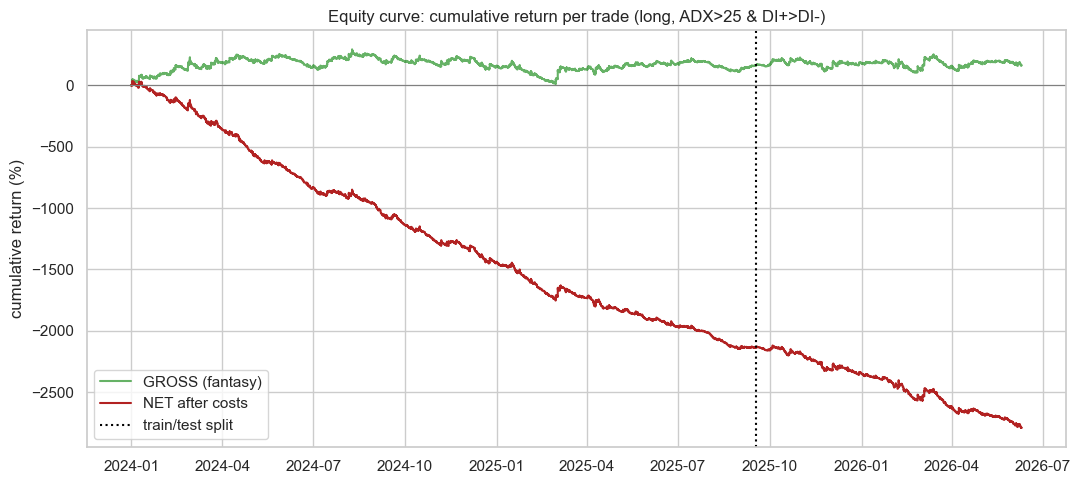

cost drag over the whole period: 2949.7 percentage points


In [5]:
sig_all = sig_rule(df)
rows = df[sig_all]
gross = rows['fwd_ret_10'].to_numpy()
net = gross - rows['cost_frac'].to_numpy()

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(rows['ts'].to_numpy(), np.cumsum(gross)*100, label='GROSS (fantasy)', color='green', alpha=0.6)
ax.plot(rows['ts'].to_numpy(), np.cumsum(net)*100,   label='NET after costs', color='firebrick')
ax.axvline(df.iloc[split]['ts'], color='black', linestyle=':', label='train/test split')
ax.axhline(0, color='grey', lw=0.8)
ax.set_title('Equity curve: cumulative return per trade (long, ADX>25 & DI+>DI-)')
ax.set_ylabel('cumulative return (%)'); ax.legend(); plt.tight_layout(); plt.show()
print(f'cost drag over the whole period: {(np.cumsum(gross)[-1]-np.cumsum(net)[-1])*100:.1f} percentage points')

## Block 4 · Mini sensitivity sweep
Never trust a single parameter value. Sweep the ADX threshold and watch whether the edge is a **stable plateau** (trustworthy) or a **lone spike** (overfit luck). This is a baby version of the project's Phase-8 sensitivity work.

OUT-OF-SAMPLE sensitivity to ADX threshold:

 adx_min  trades  net_bps  t_stat  win_%
      10   62783    -2.72  -19.83  43.13
      15   55122    -2.66  -17.96  43.08
      20   40806    -2.39  -13.64  43.26
      25   27350    -2.40  -10.87  42.58
      30   17466    -2.90  -10.16  42.12
      35   10884    -3.19   -8.56  41.31
      40    6529    -3.59   -7.03  41.23
      45    3639    -3.50   -4.76  42.10


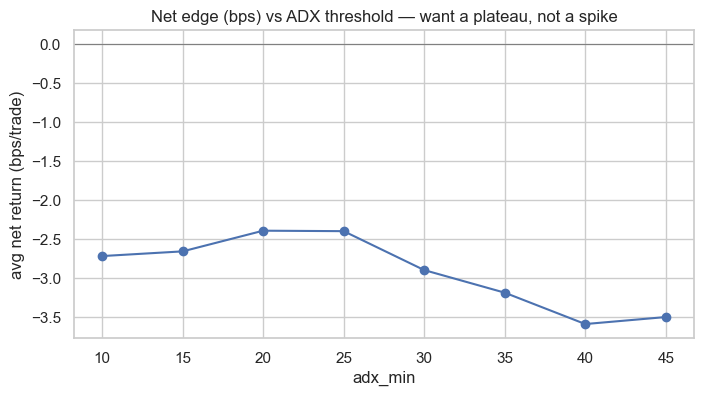

In [6]:
rows_out = []
for thr in [10,15,20,25,30,35,40,45]:
    s = (test['adx'] > thr) & (test['di_plus'] > test['di_minus'])
    _, m = backtest(test, s, 1)
    if m['trades'] > 0:
        rows_out.append({'adx_min': thr, 'trades': m['trades'],
                         'net_bps': m['avg_net_bps'], 't_stat': m['t_stat'],
                         'win_%': m['win_rate_%']})
sweep = pd.DataFrame(rows_out)
print('OUT-OF-SAMPLE sensitivity to ADX threshold:\n'); print(sweep.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(sweep['adx_min'], sweep['net_bps'], 'o-')
ax.axhline(0, color='grey', lw=0.8)
ax.set_title('Net edge (bps) vs ADX threshold — want a plateau, not a spike')
ax.set_xlabel('adx_min'); ax.set_ylabel('avg net return (bps/trade)'); plt.show()

## Block 5 · What this backtest is NOT (intellectual honesty)
Keep this list taped to your monitor. This quick test **omits** things the real C++ tick engine handles:
- **Overlapping trades** — we treat each signal as an independent bet. In reality you can't hold 50 overlapping positions; you need position management. (Net edge per trade still tells you if signal *exists*.)
- **Intrabar SL/TP** — we exit on a fixed 10-bar clock, not on stop-loss/take-profit hits *within* a bar. Real fills happen tick-by-tick.
- **Path dependence & slippage realism** — fixed-bps cost is an approximation; real slippage varies with volatility/liquidity.
- **Compounding & position sizing / risk limits** — we sum simple returns; no equity-scaling, no daily-drawdown breaker.
- **Regime shifts** — one train/test split ≠ walk-forward across many windows.

So treat a positive result here as a **green light to investigate**, never as a deployable strategy. The pipeline exists precisely because this notebook *can't* be the final word: vectorized filter → C++ tick backtest → sensitivity → walk-forward → Monte Carlo → MQL5 parity → demo.

## 🎯 Your turn
1. Set `SLIPPAGE_BPS = 2.0`. Does the edge survive a harsher cost assumption? (If it only works at zero costs, it doesn't work.)
2. Test the **short** side: `direction=-1` with `di_minus > di_plus`. Symmetric edge, or long-only?
3. Add a session filter using `hour` (e.g. only trade hours 13–20 UTC). Does focusing on active hours improve net expectancy? (Ties back to notebook 01's hour analysis.)
4. Change the holding horizon: swap `fwd_ret_10` for `fwd_ret_20` in the load query. Does a longer hold beat the extra market exposure?
5. Honest question to sit with: your sweep in Block 4 — is it a plateau or a spike? Would you bet real money on the best single cell? Why not?